<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Scalable UK Housing Clustering with ColumnTransformer, Mini-Batch K-Means and BIRCH–HAC

This notebook describes a scalable unsupervised clustering pipeline for large-scale UK housing/building stock data. It contrasts a **Mini-Batch K-Means baseline** with a **hybrid BIRCH + HAC approach** designed to make hierarchical clustering feasible at scale.

The notebook is structured as follows:

1. **Setup & EDA**
2. **Why Not Plain HAC**
3. **Preprocessing Pipeline**
4. **Mini-Batch K-Means**
5. **Hybrid BIRCH + HAC Model**
6. **Cluster Profiling**

## Real-World Applicability and Next Steps

Although the proposed clustering approach is technically scalable, **scalability alone does not guarantee real-world usefulness**. The resulting clusters need to be assessed against meaningful and actionable housing archetypes, rather than relying solely on internal clustering metrics.

For example, a complementary approach is presented in the study **"A Rule-Based Method for Classifying Housing Archetypes"**, which uses domain-informed rules to classify housing archetypes:

https://github.com/hellomayzune/A-Rule-Based-Method-for-Classifying-Housing-Archetypes-

A key next step is therefore to **validate whether the data-driven clusters correspond to meaningful housing archetypes** and determine whether they provide practical value for applications such as housing-stock analysis, energy assessment, retrofit planning, or policy development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import Birch, AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Load data
df = pd.read_csv('./SourceFileClean/CSV_UKBe16_Resi_SouthYorkshire-clean.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614460 entries, 0 to 614459
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   premise_age          614460 non-null  object 
 1   premise_type         614460 non-null  object 
 2   premise_floor_count  614402 non-null  float64
 3   bungalow             449574 non-null  object 
 4   height               614292 non-null  float64
 5   building_area        614460 non-null  float64
 6   gross_area           614402 non-null  float64
dtypes: float64(4), object(3)
memory usage: 32.8+ MB


In [4]:
df.head(3)

,premise_age,premise_type,premise_floor_count,bungalow,height,building_area,gross_area
0,Post 1999,Semi-detached,2.0,Not a bungalow,10.2,245.2,490.4
1,1960-1979,Detached,1.0,Bungalow (high confidence),6.3,194.7,194.7
2,1990-1999,Detached,1.0,Bungalow (moderate confidence),7.1,128.1,128.1


# 1. Setup & EDA 
- Loads `CSV_UKBe16_Resi_SouthYorkshire-clean.csv` — residential premises data with fields such as `premise_type`, `premise_age`, `premise_floor_count`, `bungalow`, `height`, `building_area`, and `gross_area`.
- Visualizes categorical distributions (premise types and age eras), building height/area distributions, and a numerical feature correlation heatmap.


In [5]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_sns_config = {'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14}
plt.rcParams.update(fig_sns_config)

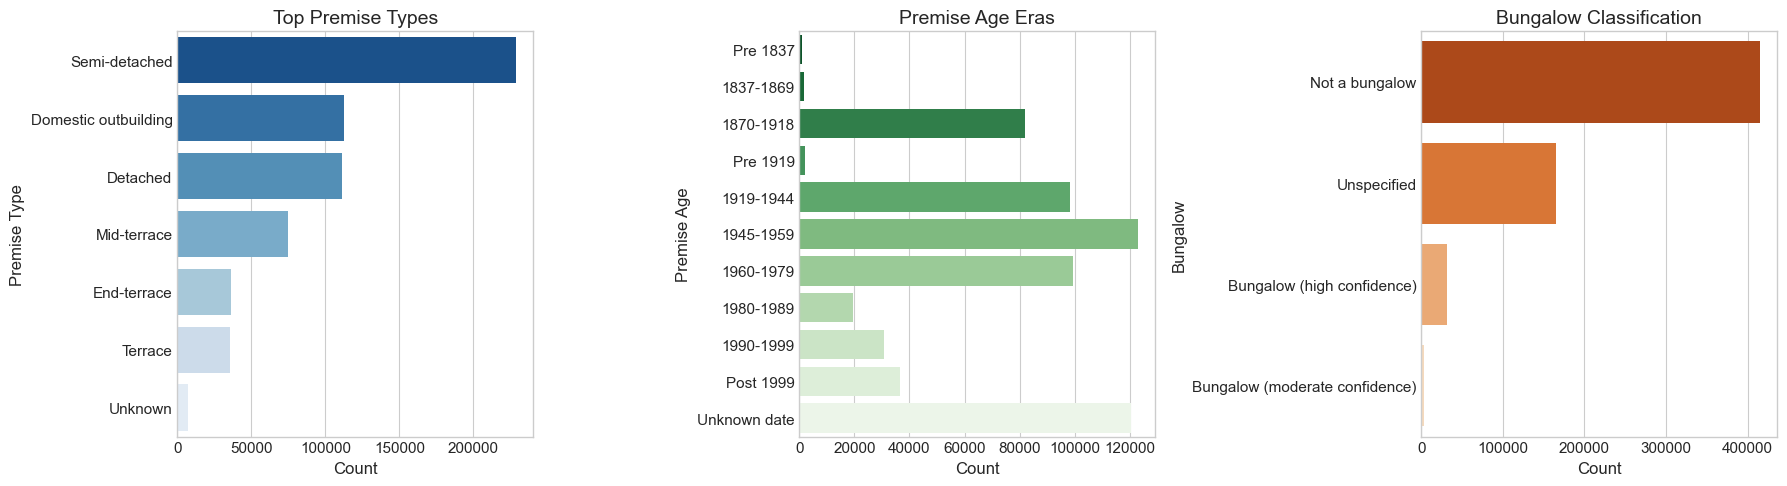

In [6]:
df_viz = df.copy()
df_viz['bungalow'] = df_viz['bungalow'].fillna('Unspecified')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Figure 1: Categorical Distributions (Updated to fix Seaborn warning)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top Premise Types
type_counts = df_viz['premise_type'].value_counts().head(7).reset_index()
type_counts.columns = ['premise_type', 'count']
sns.barplot(
    data=type_counts, 
    x='count', 
    y='premise_type', 
    hue='premise_type', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Top Premise Types')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Premise Type')

# Premise Age Eras
age_order = ['Pre 1837', '1837-1869', '1870-1918', 'Pre 1919', '1919-1944', '1945-1959', '1960-1979', '1980-1989', '1990-1999', 'Post 1999', 'Unknown date']
age_counts = df_viz['premise_age'].value_counts().reindex([a for a in age_order if a in df_viz['premise_age'].values]).reset_index()
age_counts.columns = ['premise_age', 'count']
sns.barplot(
    data=age_counts, 
    x='count', 
    y='premise_age', 
    hue='premise_age', 
    palette='Greens_r', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Premise Age Eras')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Premise Age')

# Bungalow Classification
bung_counts = df_viz['bungalow'].value_counts().reset_index()
bung_counts.columns = ['bungalow', 'count']
sns.barplot(
    data=bung_counts, 
    x='count', 
    y='bungalow', 
    hue='bungalow', 
    palette='Oranges_r', 
    legend=False, 
    ax=axes[2]
)
axes[2].set_title('Bungalow Classification')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Bungalow')

plt.tight_layout()
#plt.savefig('eda_categorical_distributions_fixed.png', dpi=300)
#plt.close()

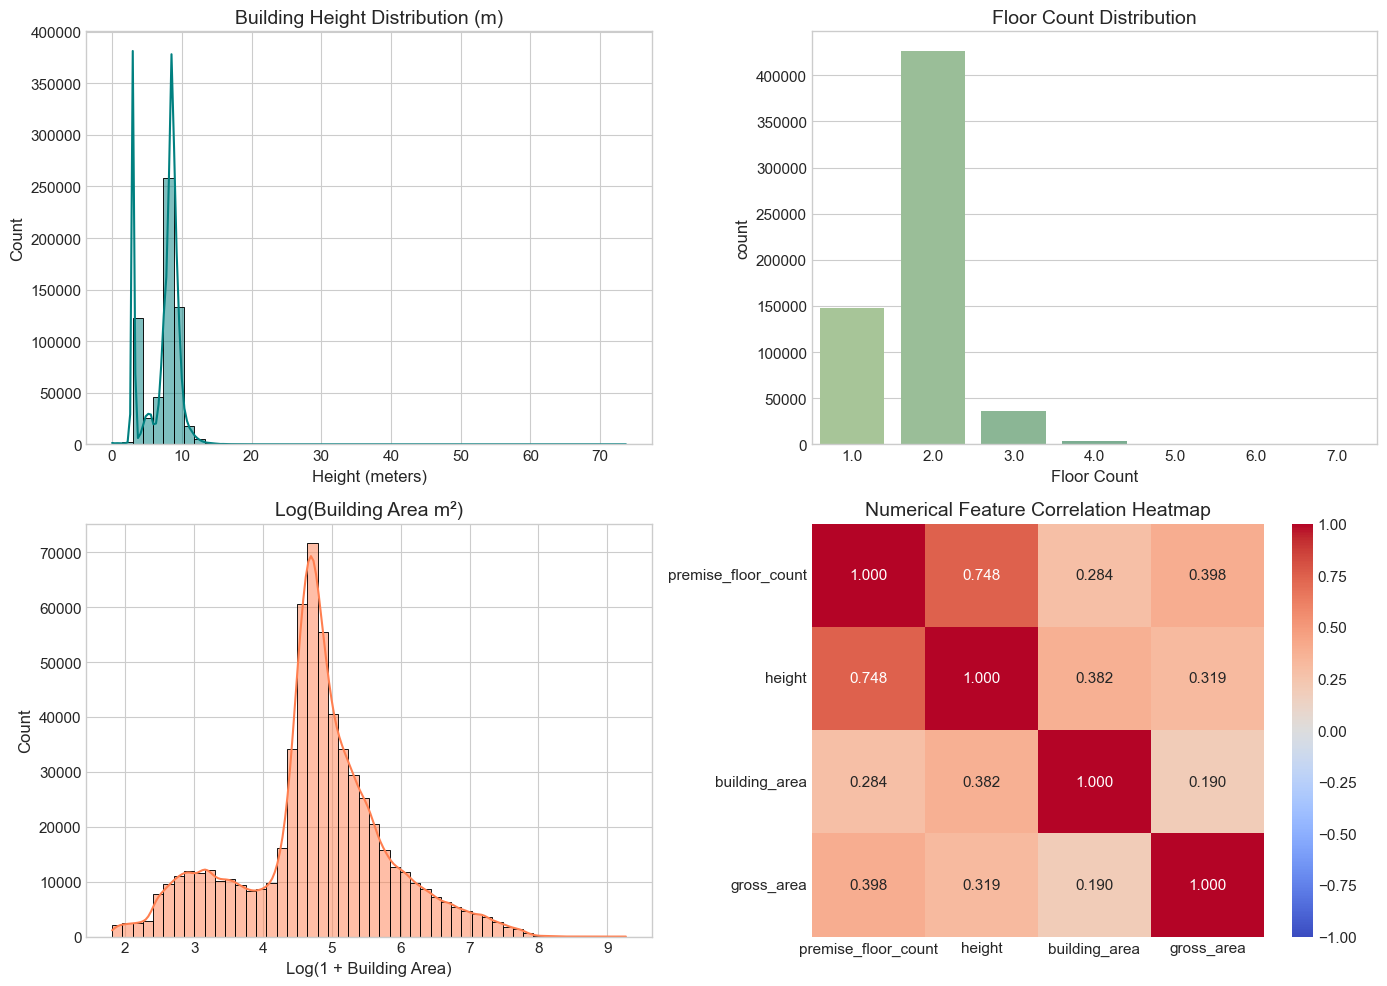

In [7]:
# Figure 2: Floor Count Distribution (countplot fix)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_viz['height'].dropna(), bins=50, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Building Height Distribution (m)')
axes[0,0].set_xlabel('Height (meters)')

sns.countplot(
    data=df_viz, 
    x='premise_floor_count', 
    hue='premise_floor_count', 
    palette='crest', 
    legend=False, 
    ax=axes[0,1]
)
axes[0,1].set_title('Floor Count Distribution')
axes[0,1].set_xlabel('Floor Count')
axes[0,1].set_xlim(-0.5, 6.5)

sns.histplot(np.log1p(df_viz['building_area']), bins=50, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Log(Building Area m²)')
axes[1,0].set_xlabel('Log(1 + Building Area)')

corr = df_viz[['premise_floor_count', 'height', 'building_area', 'gross_area']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[1,1], vmin=-1, vmax=1)
axes[1,1].set_title('Numerical Feature Correlation Heatmap')

plt.tight_layout()
#plt.savefig('eda_numerical_distributions_fixed.png', dpi=300)
#plt.close()

#print("Executed without Seaborn deprecation warnings.")

# 2. Limitations of hierarchical clustering - Housing Stock Clustering Analysis

This housing stock dataset contains **614,460 residential property records** across seven features:

- `premise_age`
- `premise_type`
- `premise_floor_count`
- `bungalow`
- `height`
- `building_area`
- `gross_area`

### 1. Early Merges and Suboptimal Results

Hierarchical Agglomerative Clustering (HAC) builds clusters bottom-up by greedily merging the two closest clusters at each step. Because HAC cannot unmerge or reassign points once a decision is made, early sub-optimal decisions can permanently affect higher-level cluster structures in this dataset.

### 2. Limitations of Hierarchical Agglomerative Clustering

HAC is unsuitable for this dataset due to its high computational requirements. With **614,460 records**, calculating pairwise distances would require over **700 GB of memory**, making direct HAC impractical.

The method is also sensitive to extreme outliers, such as unusually large buildings or heights, which can distort cluster formation. Additionally, the dataset contains both numerical and categorical features. One-hot encoding categorical variables increases dimensionality, causing distances to become less meaningful due to the **curse of dimensionality**.

Therefore, sampling or alternative clustering methods are recommended.

### 3. HAC vs. K-Means

HAC and K-Means differ significantly in their approach and efficiency. HAC makes irreversible cluster merges, is computationally expensive, and is highly sensitive to outliers. However, it can identify non-spherical cluster shapes and does not require the number of clusters to be specified in advance.

In contrast, **K-Means** iteratively reallocates data points, making it more flexible and efficient for large datasets. It requires the number of clusters (`K`) to be chosen beforehand and generally works best with spherical, well-separated clusters.

### 4. Mitigation Strategies

Several strategies can improve clustering performance:

- **BIRCH or Mini-Batch K-Means** can reduce the 614,460 records into smaller representative clusters before applying hierarchical clustering.
- **Robust scaling** using the median and interquartile range can reduce the influence of extreme values.
- Severe outliers can be **filtered or treated separately**.
- For mixed numerical and categorical data, **Gower’s Distance** provides a suitable similarity measure.
- Dimensionality reduction methods such as **UMAP** can simplify the data.
- Alternatively, **HDBSCAN** can identify dense clusters while treating outliers as noise rather than forcing them into clusters

# 3. Data Processing and Clustering Script

- Builds a `ColumnTransformer`/`Pipeline` using:
  - `StandardScaler`
  - `OneHotEncoder`
  - `SimpleImputer`
- Converts categorical features such as `premise_age` and `premise_type` into numeric form (`X_processed`), preparing the data for scalable clustering.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Set plot design
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ---------------------------------------------------------
# Step 1: Load Dataset
# ---------------------------------------------------------

# Use the same import

# ---------------------------------------------------------
# Step 2: Numerical Conversion for 'premise_age' & 'premise_type'
# ---------------------------------------------------------

# A. Convert 'premise_age' to numerical representative mid-point years
age_band_to_year = {
    'Pre 1919': 1900,
    '1919-1944': 1931,
    '1945-1959': 1952,
    '1960-1979': 1970,
    '1980-1989': 1985,
    '1990-1999': 1995,
    'Post 1999': 2010
}

# Map age strings to numeric year; calculate property age in years (relative to 2026)
df['premise_age_numeric'] = df['premise_age'].map(age_band_to_year)
# Fallback for unmapped or missing values via median imputation downstream
CURRENT_YEAR = 2026
df['property_age_years'] = CURRENT_YEAR - df['premise_age_numeric']

# B. Convert 'bungalow' flag to numerical confidence scale
bungalow_map = {
    'Not a bungalow': 0.0,
    'Bungalow (moderate confidence)': 0.5,
    'Bungalow (high confidence)': 1.0
}
df['bungalow_numeric'] = df['bungalow'].map(bungalow_map)

# C. Specify feature groups
num_cols = ['property_age_years', 'premise_floor_count', 'height', 
            'building_area', 'gross_area', 'bungalow_numeric']
cat_cols = ['premise_type']

# ---------------------------------------------------------
# Step 3: Feature Engineering Pipeline (Encoding + Imputation + Scaling)
# ---------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Fit and transform dataset into a fully numerical feature matrix
X_processed = preprocessor.fit_transform(df)

# Retrieve feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

print(f"Processed Feature Matrix Shape: {X_processed.shape}")

Processed Feature Matrix Shape: (614460, 16)


# 4. Mini-Batch K-Means Clustering

- Uses Mini-Batch K-Means as a fast, scalable baseline.
- Sweeps **K = 3–7**.
- Fits `MiniBatchKMeans` on the full dataset.
- Evaluates cluster quality using:
  - Silhouette Score
  - Calinski-Harabasz Index
  - Davies-Bouldin Index
- Metrics are calculated on a **50,000-point stratified sample** to keep evaluation tractable.

In [9]:
# Evaluate optimal K for Mini-Batch K-Means
k_values = range(3, 8)
mbk_models = {}
metrics_summary = []

# Take a stratified random sample for evaluation metrics
sample_size = 50000
np.random.seed(42)
sample_idx = np.random.choice(X_processed.shape[0], size=sample_size, replace=False)
X_sample = X_processed[sample_idx]

for k in k_values:
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=4096, random_state=42, n_init=3)
    labels = mbk.fit_predict(X_processed)
    mbk_models[k] = mbk
    
    # Calculate evaluation metrics on sample
    sample_labels = labels[sample_idx]
    sil = silhouette_score(X_sample, sample_labels)
    ch = calinski_harabasz_score(X_sample, sample_labels)
    db = davies_bouldin_score(X_sample, sample_labels)
    
    metrics_summary.append({
        'K': k,
        'Inertia': mbk.inertia_,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db
    })

metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df.to_string(index=False))

# Assign optimal cluster labels (e.g., K=4)
df['cluster_mbk'] = mbk_models[4].labels_

 K      Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
 3 2.625257e+06    0.315936       14837.842664        1.524216
 4 1.963653e+06    0.414483       19686.097608        1.014836
 5 1.587987e+06    0.446612       22440.339462        0.907616
 6 1.470527e+06    0.424683       20593.184122        1.161524
 7 1.361929e+06    0.433559       19900.727870        1.067250


# 5. Hybrid BIRCH + HAC Model

- Uses BIRCH as the core scalability technique.
- BIRCH first compresses the **600K+ records** into a much smaller set of sub-cluster centroids.
- True Agglomerative Hierarchical Clustering using **Ward linkage** is then applied only to these centroids, with a target of **4 clusters**.
- This combines HAC's hierarchical structure with BIRCH's scalability.
- The resulting cluster labels are mapped back to all original rows.

In [10]:
# Step 4A: Fit BIRCH to reduce dimension and compress dataset size
birch_threshold = 0.5
birch_branching = 50
birch = Birch(threshold=birch_threshold, branching_factor=birch_branching, n_clusters=None)
birch.fit(X_processed)

# Extract sub-cluster centroids
centroids = birch.subcluster_centers_
print(f"BIRCH reduced dataset from {X_processed.shape[0]} to {centroids.shape[0]} centroids.")

# Step 4B: Run Agglomerative Clustering on the compressed centroids
target_clusters = 4
hac = AgglomerativeClustering(n_clusters=target_clusters, linkage='ward')
centroid_labels = hac.fit_predict(centroids)

# Step 4C: Map centroid labels back to all original data points
df['cluster_birch_hac'] = birch.predict(X_processed)
subcluster_to_final = {i: centroid_labels[i] for i in range(len(centroids))}
df['cluster_birch_hac'] = df['cluster_birch_hac'].map(subcluster_to_final)

BIRCH reduced dataset from 614460 to 5197 centroids.


# 6. Cluster Profiling & Comparison

- Compares clusters using mean values of:
  - `property_age_years`
  - `premise_floor_count`
  - `height`
  - `building_area`
  - `gross_area`
- Cross-tabulates the `premise_type` distribution for each cluster.
- Uses these statistics to characterize and interpret what each housing cluster represents.

In [11]:
# Profile clusters using converted numerical features
profile_features = ['property_age_years', 'premise_floor_count', 'height', 'building_area', 'gross_area']

# Mean feature values per cluster for Hybrid BIRCH + HAC
cluster_profile = df.groupby('cluster_birch_hac')[profile_features].mean().round(2)

# Include original categorical counts for validation
type_distribution = pd.crosstab(df['cluster_birch_hac'], df['premise_type'], normalize='index').round(3) * 100

print("--- Numerical Cluster Profile (Averages) ---")
print(cluster_profile)
print("\n--- Premise Type Distribution per Cluster (%) ---")
print(type_distribution)

--- Numerical Cluster Profile (Averages) ---
                   property_age_years  premise_floor_count  height  \
cluster_birch_hac                                                    
0                               64.94                 1.83    7.32   
1                               33.59                 6.74   21.93   
2                               45.00                 8.00   24.50   
3                               41.59                 5.72   18.47   

                   building_area  gross_area  
cluster_birch_hac                             
0                         203.20      126.78  
1                        2439.79    11691.25  
2                        9214.05    51236.60  
3                        1311.26     3951.41  

--- Premise Type Distribution per Cluster (%) ---
premise_type       Detached  Domestic outbuilding  Enclosed end-terrace  \
cluster_birch_hac                                                         
0                      18.0                  18.4  

# Visualisation

## 1. Heatmap of Scaled Means

Purpose: Fast cluster comparison across all metrics

In [15]:
# Fit and transform dataset into a fully numerical feature matrix
X_processed = preprocessor.fit_transform(df)

# Alias for visualization scripts
X_scaled = X_processed

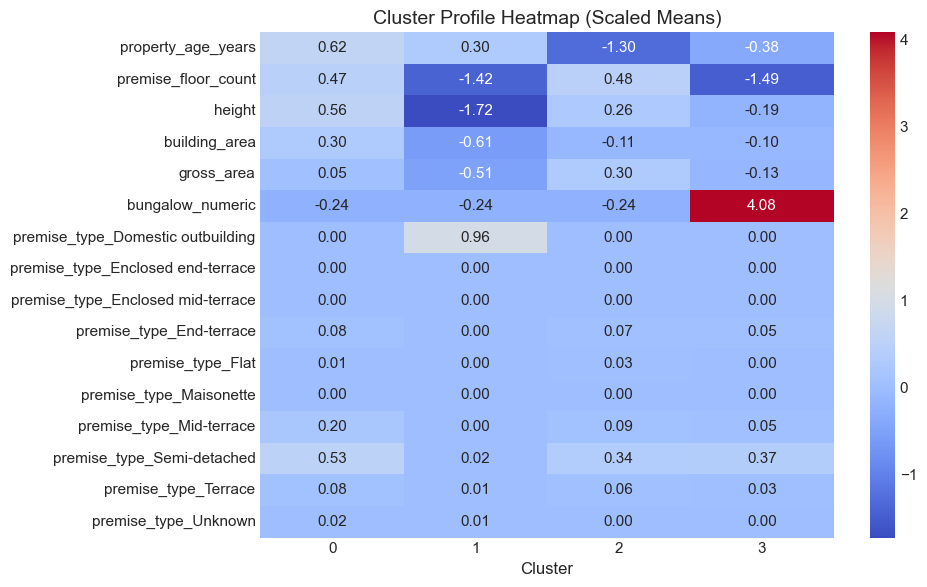

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

# Build scaled profile DataFrame using X_processed
profile_scaled = pd.DataFrame(X_processed, columns=all_feature_names)
profile_scaled['Cluster'] = df['cluster_mbk']

plt.figure(figsize=(10, 6))
sns.heatmap(profile_scaled.groupby('Cluster').mean().T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Profile Heatmap (Scaled Means)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

### 2. PCA Scatter Plot (Subsample for speed/clarity)

Purpose: Visual validation of cluster separation

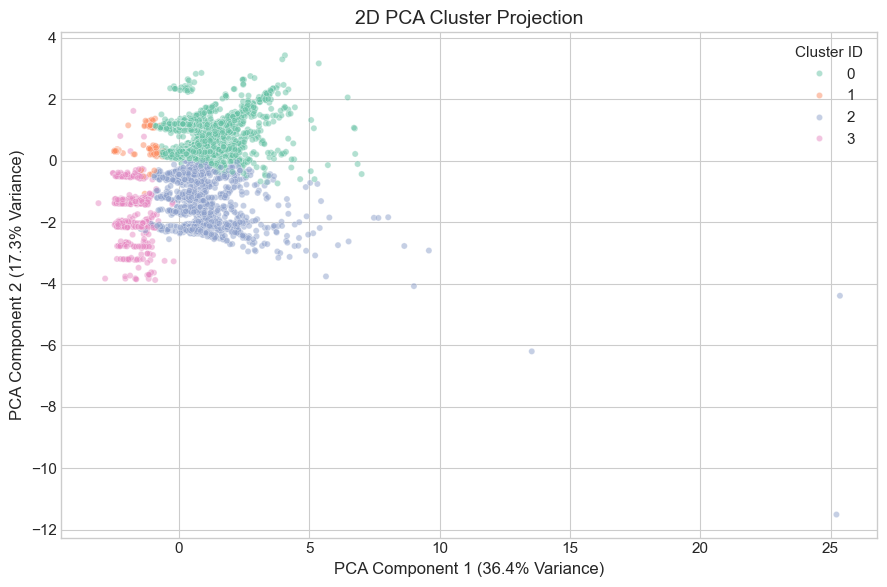

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Take a sub-sample of the dataset for fast rendering
np.random.seed(42)
sample_idx = np.random.choice(X_processed.shape[0], size=10000, replace=False)

# 2. Fit PCA on the sampled features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed[sample_idx])

# 3. Plot using 'cluster_mbk' (or 'cluster_birch_hac')
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df['cluster_mbk'].iloc[sample_idx],  # Updated column name
    palette='Set2', 
    alpha=0.5, 
    s=20
)

plt.title('2D PCA Cluster Projection')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend(title='Cluster ID')
plt.tight_layout()
plt.show()

### 3. Categorical Composition Bar Chart (Premise Type)

Purpose: Understanding architectural mix per cluster

<Figure size 1000x600 with 0 Axes>

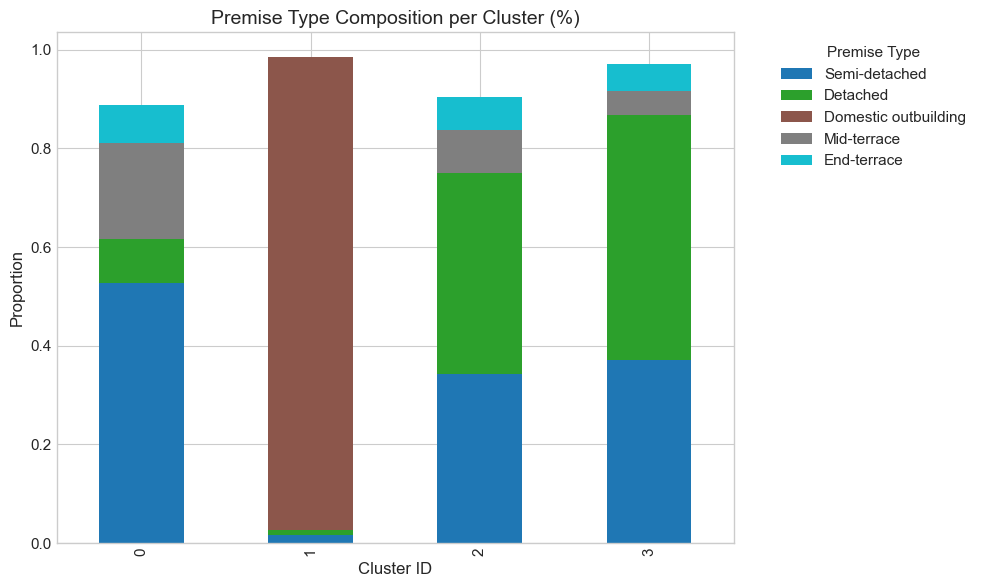

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compute cross-tabulation using 'cluster_mbk' (or 'cluster_birch_hac')
type_comp = pd.crosstab(df['cluster_mbk'], df['premise_type'], normalize='index')

# 2. Select top premise types for cleaner visualization
top_types = type_comp.sum().nlargest(5).index

# 3. Plot 100% stacked bar chart
plt.figure(figsize=(10, 6))
type_comp[top_types].plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

plt.title('Premise Type Composition per Cluster (%)')
plt.xlabel('Cluster ID')
plt.ylabel('Proportion')
plt.legend(title='Premise Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Violin / Boxplot for Building Area across Clusters

Purpose: Outlier detection & variance analysis

C:\Users\mayzu\AppData\Local\Temp\ipykernel_21776\3399878099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


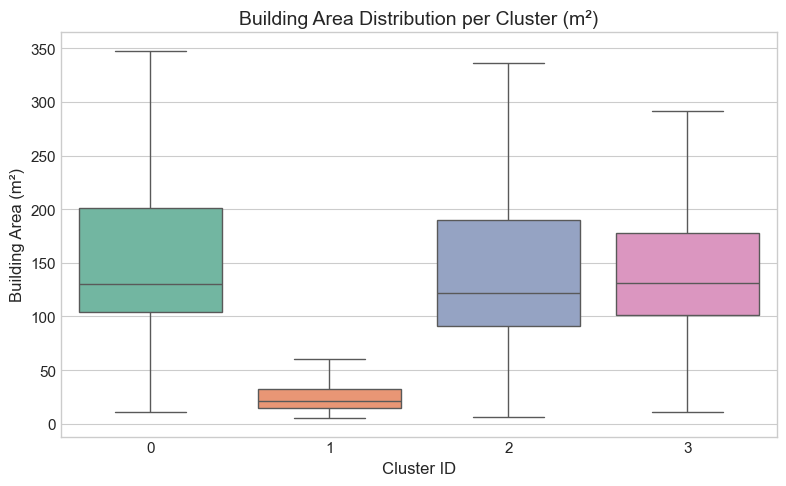

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out extreme outliers for better plot scaling
plot_df = df[df['building_area'] < 500]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df, 
    x='cluster_mbk',  
    y='building_area', 
    palette='Set2', 
    showfliers=False
)

plt.title('Building Area Distribution per Cluster (m²)')
plt.xlabel('Cluster ID')
plt.ylabel('Building Area (m²)')
plt.tight_layout()
plt.show()

C:\Users\mayzu\AppData\Local\Temp\ipykernel_21776\3346110610.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


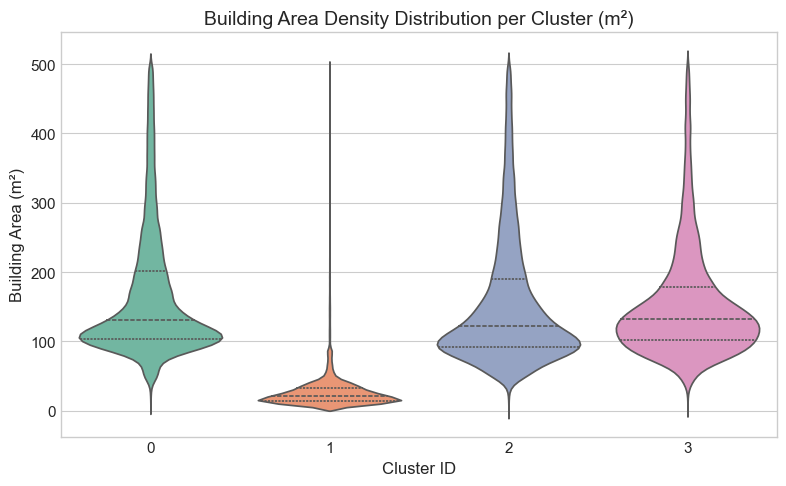

In [26]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=plot_df, 
    x='cluster_mbk', 
    y='building_area', 
    palette='Set2',
    inner='quartile'
)

plt.title('Building Area Density Distribution per Cluster (m²)')
plt.xlabel('Cluster ID')
plt.ylabel('Building Area (m²)')
plt.tight_layout()
plt.show()

### 5. Cluster Profile Heatmap (Z-Scores / Scaled Means)

Purpose: Provides a high-level executive summary of cluster archetypes by displaying how much each feature deviates from the dataset mean (standardized z-scores).

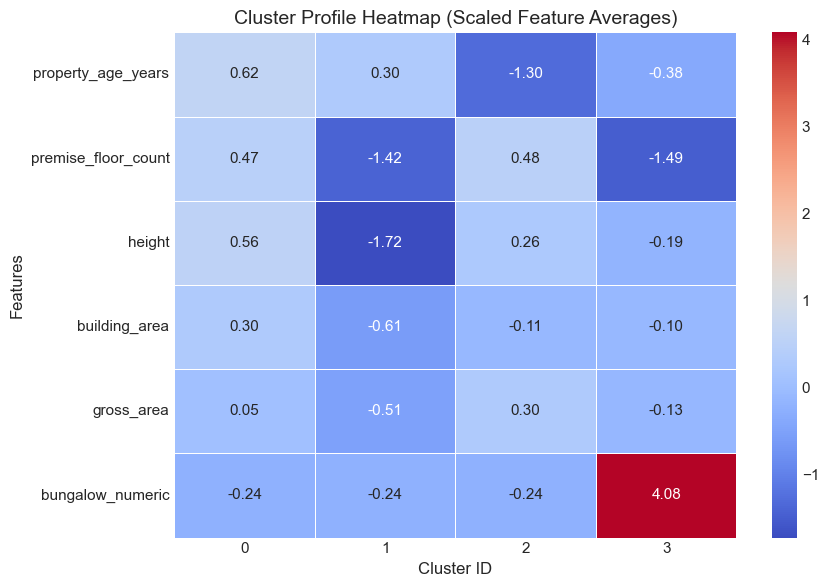

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Dynamically retrieve feature names from the preprocessor pipeline
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
features = num_cols + encoded_cat_cols

# 2. Build scaled profile DataFrame
profile_scaled = pd.DataFrame(X_processed, columns=features)

# Use 'cluster_mbk' or 'cluster' alias
cluster_col = 'cluster' if 'cluster' in df.columns else 'cluster_mbk'
profile_scaled['Cluster'] = df[cluster_col]

# 3. Compute scaled feature means per cluster (showing top numerical features for clarity)
heatmap_data = profile_scaled.groupby('Cluster')[num_cols].mean().T

# 4. Plot Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Cluster Profile Heatmap (Scaled Feature Averages)')
plt.xlabel('Cluster ID')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 6. Feature Distribution Boxplots / Violin Plots

Purpose: Evaluates the internal variance, skewness, and outliers of critical physical dimensions (e.g., `building_area` or `height`) within each cluster.

C:\Users\mayzu\AppData\Local\Temp\ipykernel_21776\242546393.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\mayzu\AppData\Local\Temp\ipykernel_21776\242546393.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


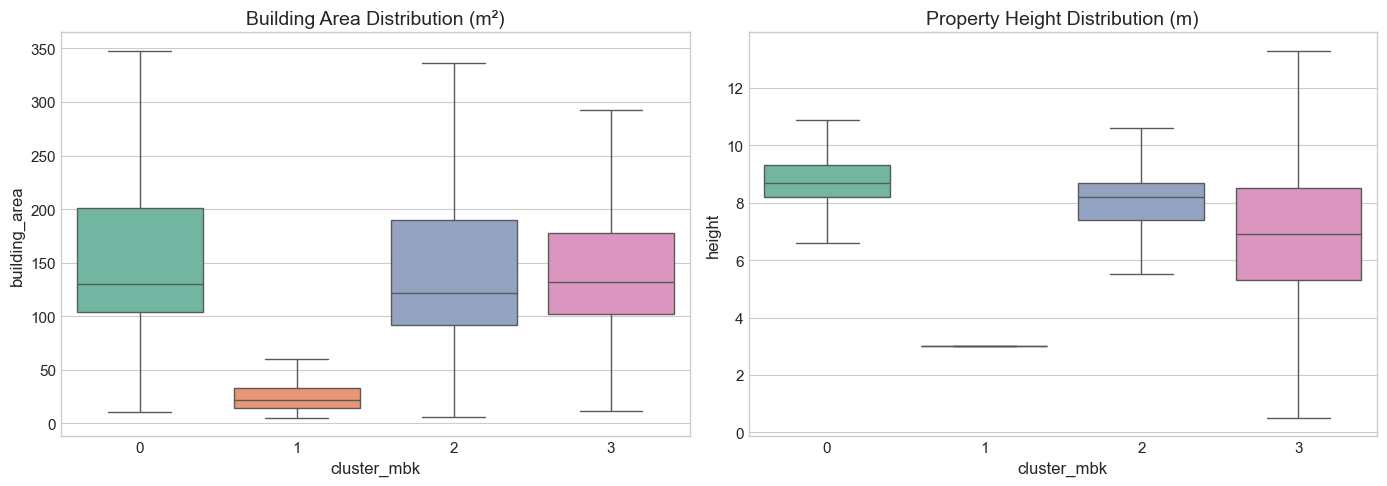

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Building Area distribution
sns.boxplot(
    data=df[df['building_area'] < 500], x='cluster_mbk', y='building_area', 
    palette='Set2', ax=axes[0], showfliers=False
)
axes[0].set_title('Building Area Distribution (m²)')

# Height distribution
sns.boxplot(
    data=df, x='cluster_mbk', y='height', 
    palette='Set2', ax=axes[1], showfliers=False
)
axes[1].set_title('Property Height Distribution (m)')

plt.tight_layout()
plt.show()

### 7. Parallel Coordinates Plot

Purpose: Traces multi-metric feature pathways across clusters to observe multi-variable trade-offs (e.g., small footprint combined with high floor count vs. large footprint with low height).

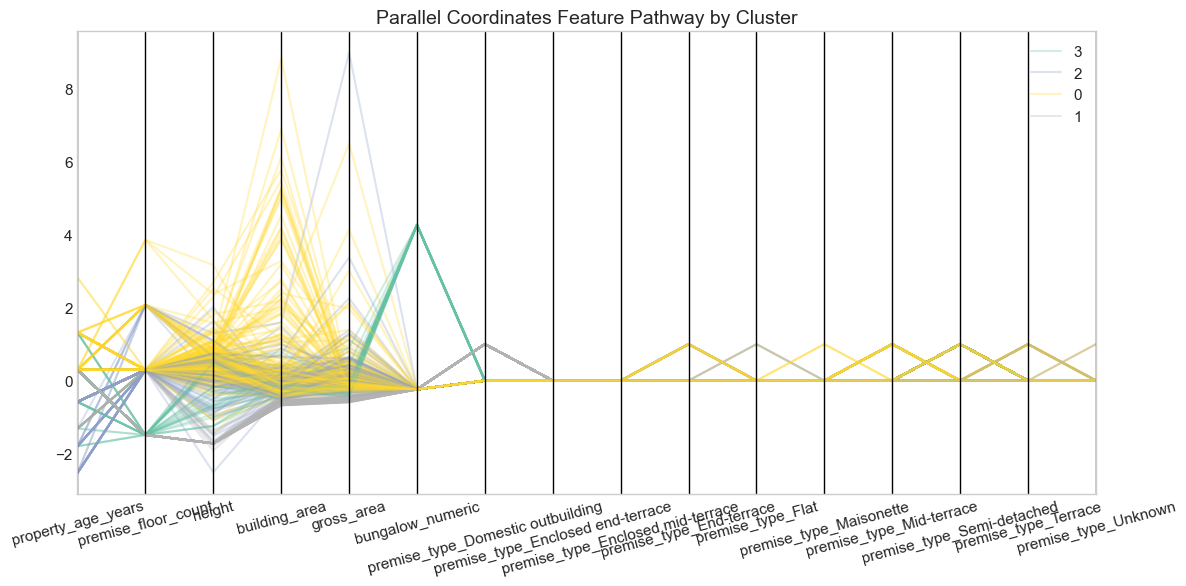

In [32]:
from pandas.plotting import parallel_coordinates

# Prepare sample dataset with normalized features and cluster labels
df_sample = pd.DataFrame(X_scaled[sample_idx], columns=features)
df_sample['Cluster'] = df['cluster_mbk'].iloc[sample_idx].values.astype(str)

plt.figure(figsize=(12, 6))
parallel_coordinates(df_sample.sample(500, random_state=42), 'Cluster', colormap='Set2', alpha=0.3)
plt.title('Parallel Coordinates Feature Pathway by Cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()